# VGG — Simonyan & Zisserman (2014), explained

Paper: *Very Deep Convolutional Networks for Large-Scale Image Recognition*.

Goal of this notebook: **understand the architecture**, not to build a framework.
Anything PyTorch already provides (`nn.Conv2d`, `nn.MaxPool2d`, `nn.ReLU`, `CrossEntropyLoss`,
`SGD`, `DataLoader`) is used as-is.

Here the paper's ImageNet task is swapped for **individual tiger identification** on the
[ATRW](https://cvwc2019.github.io/challenge.html) re-ID dataset: given a photo of a tiger, name
*which* of 107 known tigers it is.

**Layout**
1. Load the data
2. Helper functions, and why each one exists
3. The architecture — every layer, and the training step line by line
4. Train
5. Predict and validate
6. Glossary

**What the paper specifies** (kept): 13 convolutional layers, ReLU non-linearity,
max-pooling, and 3 fully connected layers.

**Where this adapts** (two places, on purpose):
- Paper's output is 1000 ImageNet classes. Here: output is **107 tiger identities**.
- Paper trained on large ImageNet images. Here we keep a simpler resize-and-normalize
  pipeline because ATRW is much smaller.


# Section 1 — Loading the data

**ATRW (Amur Tiger Re-identification in the Wild), reid split**: photos of Amur tigers cropped
around the animal, each tagged with the identity of the tiger in it.

```
benchmarks/atrw_dataset_reid_tiger/
├── atrw_anno_reid_train/reid_list_train.csv   id, filename  (labelled)
├── atrw_reid_train/train/*.jpg                labelled + extra unlabelled crops
├── atrw_anno_reid_test/reid_list_test.csv     filename only (no id — used for the
│                                               official retrieval leaderboard, not
│                                               classification, so it's no use here)
└── atrw_reid_test/test/*.jpg
```

Two details this notebook works around:
- The train **folder** has 3,392 images but the train **CSV** only labels 1,887 of them (the
  rest are unlabelled crops used elsewhere in ATRW, e.g. pose estimation). We only use the
  1,887 labelled rows.
- The official test CSV has no identity labels. So "test" here means a held-out **validation
  split carved out of the labelled training rows** (stratified by tiger id), not the
  `atrw_reid_test` folder — there is no ground truth to score against there.

Two things happen to every image before it reaches the network:
- **Resize to 224×224.** VGG uses a fixed, standard RGB input size, which keeps the design
  consistent and simple across blocks.
- **Normalise.** Pixel values are normalised channel-wise so optimisation is stable and faster.


In [1]:
import csv
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

DATA_ROOT = Path("benchmarks/atrw_dataset_reid_tiger")
TRAIN_IMG_DIR = DATA_ROOT / "atrw_reid_train" / "train"
TRAIN_CSV = DATA_ROOT / "atrw_anno_reid_train" / "reid_list_train.csv"

print("torch", torch.__version__, "| device:", DEVICE)


torch 2.12.1+cu126 | device: cuda


In [2]:
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),            # fixed VGG-style input size
    transforms.ToTensor(),                     # PIL -> (3,224,224) float in 0..1
    transforms.Normalize(NORM_MEAN, NORM_STD),
])


def read_labels(csv_path):
    """CSV rows are 'id,filename' -> [(filename, id), ...]."""
    rows = []
    with open(csv_path, newline="") as f:
        for tiger_id, filename in csv.reader(f):
            rows.append((filename, int(tiger_id)))
    return rows


class TigerReIDDataset(Dataset):
    """One row = one photo of one tiger. Loads and transforms lazily, like any real dataset
    (unlike MNIST, these images don't fit comfortably as one big in-memory tensor)."""

    def __init__(self, samples, img_dir, class_to_idx, transform):
        self.samples = samples                   # [(filename, tiger_id), ...]
        self.img_dir = img_dir
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        filename, tiger_id = self.samples[i]
        img = Image.open(self.img_dir / filename).convert("RGB")
        return self.transform(img), self.class_to_idx[tiger_id]


def stratified_split(rows, val_fraction=0.15, seed=0):
    """Hold out val_fraction of EACH tiger's photos, so every identity appears in both splits
    (a plain random split could leave a rare tiger with zero training photos)."""
    import random
    by_id = {}
    for filename, tiger_id in rows:
        by_id.setdefault(tiger_id, []).append(filename)

    rng = random.Random(seed)
    train_rows, val_rows = [], []
    for tiger_id, files in by_id.items():
        files = files[:]
        rng.shuffle(files)
        n_val = max(1, round(len(files) * val_fraction))
        for f in files[:n_val]:
            val_rows.append((f, tiger_id))
        for f in files[n_val:]:
            train_rows.append((f, tiger_id))
    return train_rows, val_rows


def load_data():
    rows = read_labels(TRAIN_CSV)                                # 1,887 labelled (filename, id) pairs
    tiger_ids = sorted({tiger_id for _, tiger_id in rows})        # 107 real tiger ids, e.g. 1, 10, 96...
    class_to_idx = {tid: i for i, tid in enumerate(tiger_ids)}    # -> 0..106, what CrossEntropyLoss wants

    train_rows, val_rows = stratified_split(rows, val_fraction=0.15)
    tr = TigerReIDDataset(train_rows, TRAIN_IMG_DIR, class_to_idx, transform)
    te = TigerReIDDataset(val_rows, TRAIN_IMG_DIR, class_to_idx, transform)
    return tr, te, len(tiger_ids)


In [3]:
train_ds, test_ds, N_CLASSES = load_data()

print(f"{N_CLASSES} tiger identities | train: {len(train_ds)}  val/'test': {len(test_ds)}")
x0, y0 = train_ds[0]
print("one sample:", tuple(x0.shape), "label", int(y0),
      "| pixel range", float(x0.min()), "to", float(x0.max()))


107 tiger identities | train: 1588  val/'test': 299
one sample: (3, 224, 224) label 93 | pixel range -1.0561692714691162 to 1.942832350730896


In [4]:
# DataLoader = PyTorch's batching + shuffling. No reason to write our own.
BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

xb, yb = next(iter(train_loader))
print("one batch:", tuple(xb.shape), "labels", tuple(yb.shape))

one batch: (64, 3, 224, 224) labels (64,)


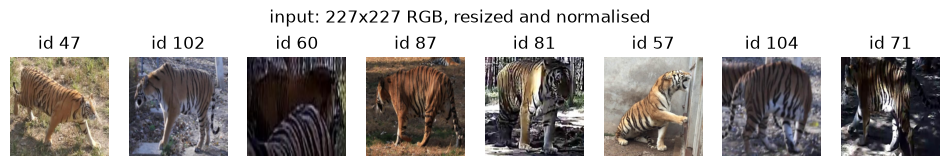

In [5]:
# Look at what we're feeding the network.
import matplotlib.pyplot as plt


def unnormalize(img):
    """(3,H,W) normalized tensor -> (H,W,3) array in 0..1, for display only."""
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std = torch.tensor(NORM_STD).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, lab in zip(axes, xb, yb):
    ax.imshow(unnormalize(img)); ax.set_title(f"id {int(lab)}"); ax.axis("off")
plt.suptitle("input: 227x227 RGB, resized and normalised")
plt.show()

# Section 2 — Helper functions, and why each exists

Four small helpers. Each answers one question you will ask while iterating.

In [6]:
def count_params(model):
    """WHY: capacity. VGG is deeper and more regular than AlexNet, so parameter count can be
    substantial; tracking capacity helps reason about overfitting risk on a smaller dataset."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def accuracy(model, loader):
    """WHY: the number you actually care about. Training loss can fall while accuracy
    stalls, so never judge a run by loss alone."""
    model.eval()                            # eval mode: turns off dropout/BN updates
    correct = total = 0
    for x, y in loader:
        pred = model(x.to(DEVICE)).argmax(1).cpu()   # argmax over the class scores
        correct += (pred == y).sum().item()
        total += len(y)
    return 100.0 * correct / total


@torch.no_grad()
def show_shapes(model, size=227, channels=3):
    """WHY: shape bugs are the most common bug in CNNs. Print what each layer does to the
    tensor so spatial downsampling is visible instead of assumed."""
    x = torch.zeros(1, channels, size, size, device=DEVICE)
    print(f"{'input':22} {tuple(x.shape)}")
    for name, layer in model.named_children():
        for sub_name, sub in layer.named_children():
            x = sub(x)
            print(f"{name}.{sub_name:<18} {tuple(x.shape)}")
    return x


def plot_history(history):
    """WHY: the shape of the curves tells you what to change next. Both losses falling
    together = keep training. Train falling, test flat or rising = overfitting."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot([h["train_loss"] for h in history], marker="o")
    ax[0].set_title("training loss"); ax[0].set_xlabel("epoch")
    ax[1].plot([h["train_acc"] for h in history], marker="o", label="train")
    ax[1].plot([h["test_acc"] for h in history], marker="o", label="test")
    ax[1].set_title("accuracy (%)"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

# Section 3 — The architecture

## The shape of the idea

VGG stacks a sequence of small 3×3 convolution blocks to learn increasingly rich features:
- early layers detect edges and colour contrasts,
- middle layers capture texture and parts,
- later layers capture object-level patterns.

VGG is often better than AlexNet because repeated 3×3 filters create a deeper, more uniform feature extractor that can model fine-grained patterns more effectively while keeping the design simple.

## The layers

| Layer | What it is | In → Out | Why |
|---|---|---|---|
| conv1_1 | 64 filters, 3×3 | 3×224×224 → 64×224×224 | learn low-level image structure |
| conv1_2 | 64 filters, 3×3 | 64×224×224 → 64×224×224 | deepen early representation |
| pool1 | max-pool 2×2, stride 2 | 64×224×224 → 64×112×112 | reduce spatial size |
| conv2_1 | 128 filters, 3×3 | 64×112×112 → 128×112×112 | richer mid-level features |
| conv2_2 | 128 filters, 3×3 | 128×112×112 → 128×112×112 | refine local patterns |
| pool2 | max-pool 2×2, stride 2 | 128×112×112 → 128×56×56 | compact the map |
| conv3_1 | 256 filters, 3×3 | 128×56×56 → 256×56×56 | stronger feature hierarchy |
| conv3_2 | 256 filters, 3×3 | 256×56×56 → 256×56×56 | learn more detailed textures |
| conv3_3 | 256 filters, 3×3 | 256×56×56 → 256×56×56 | deepen representation |
| pool3 | max-pool 2×2, stride 2 | 256×56×56 → 256×28×28 | downsample again |
| conv4_1 | 512 filters, 3×3 | 256×28×28 → 512×28×28 | high-level spatial patterns |
| conv4_2 | 512 filters, 3×3 | 512×28×28 → 512×28×28 | enhance discriminative features |
| conv4_3 | 512 filters, 3×3 | 512×28×28 → 512×28×28 | deeper abstraction |
| pool4 | max-pool 2×2, stride 2 | 512×28×28 → 512×14×14 | shrink feature map |
| conv5_1 | 512 filters, 3×3 | 512×14×14 → 512×14×14 | final feature extraction |
| conv5_2 | 512 filters, 3×3 | 512×14×14 → 512×14×14 | continue feature refinement |
| conv5_3 | 512 filters, 3×3 | 512×14×14 → 512×14×14 | deepest abstraction |
| pool5 | max-pool 2×2, stride 2 | 512×14×14 → 512×7×7 | compact representation |
| fc6 | dense 4096 | 512×7×7 → 4096 | global semantic summary |
| fc7 | dense 4096 | 4096 → 4096 | high-level classifier features |
| fc8 | dense 107 | 4096 → 107 | one score per tiger identity |

Only the final classifier size changes from the paper (1000 → 107 classes).


In [7]:
class VGG16(nn.Module):
    """VGG16-style architecture adapted to N_CLASSES outputs."""

    def __init__(self, n_classes=107):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = VGG16(n_classes=N_CLASSES).to(DEVICE)
print(model)
print("\ntrainable parameters:", count_params(model), "(VGG is deep but more regular than AlexNet)")


VGG16(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation

In [8]:
# Watch the tensor shrink and deepen through the network.
show_shapes(model);

input                  (1, 3, 227, 227)
features.0                  (1, 64, 227, 227)
features.1                  (1, 64, 227, 227)
features.2                  (1, 64, 227, 227)
features.3                  (1, 64, 227, 227)
features.4                  (1, 64, 113, 113)
features.5                  (1, 128, 113, 113)
features.6                  (1, 128, 113, 113)
features.7                  (1, 128, 113, 113)
features.8                  (1, 128, 113, 113)
features.9                  (1, 128, 56, 56)
features.10                 (1, 256, 56, 56)
features.11                 (1, 256, 56, 56)
features.12                 (1, 256, 56, 56)
features.13                 (1, 256, 56, 56)
features.14                 (1, 256, 56, 56)
features.15                 (1, 256, 56, 56)
features.16                 (1, 256, 28, 28)
features.17                 (1, 512, 28, 28)
features.18                 (1, 512, 28, 28)
features.19                 (1, 512, 28, 28)
features.20                 (1, 512, 28, 28)
fe

## What one training step actually does

Five lines, run once per batch. This is the whole of "learning".

```python
scores = model(x)                 # 1. FORWARD
loss   = criterion(scores, y)     # 2. MEASURE THE ERROR
optimizer.zero_grad()             # 3. CLEAR OLD GRADIENTS
loss.backward()                   # 4. BACKWARD  (back-propagation)
optimizer.step()                  # 5. UPDATE THE WEIGHTS
```

**1. Forward.** The batch flows through conv blocks and fully connected layers and comes out as
107 logits per image. Higher logit means the model currently prefers that tiger identity.

**2. Loss.** `CrossEntropyLoss` compares those logits against the true class and returns one
number: how wrong we were.

**3. Zero the gradients.** PyTorch accumulates gradients into `.grad` by default. Without this
line, current and previous batch gradients would mix.

**4. Backward — back-propagation.** The chain rule runs from loss to every weight and stores
sensitivity in each parameter's `.grad` tensor.

**5. Update.** The optimiser moves each weight in the direction that reduces the loss.

Repeat over the whole dataset = one **epoch**.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

x, y = next(iter(train_loader))
x, y = x.to(DEVICE), y.to(DEVICE)

# Pick one conv1 kernel weight and watch it change.
w = model.features[0].weight            # conv1 kernels, shape (96,3,11,11)
before = w[0, 0, 0, 0].item()
print("gradient before backward():", w.grad)          # None -- nothing computed yet

scores = model(x)                                     # 1. FORWARD
print("scores for one image (first 10 of", N_CLASSES, "):",
      scores[0, :10].detach().cpu().numpy().round(3))

loss = criterion(scores, y)                           # 2. HOW WRONG ARE WE
print("loss:", round(loss.item(), 4))

optimizer.zero_grad()                                 # 3. CLEAR
loss.backward()                                       # 4. BACKWARD -> fills .grad
print("gradient after backward():", round(w.grad[0, 0, 0, 0].item(), 6))

optimizer.step()                                      # 5. UPDATE
print(f"weight: {before:.6f} -> {w[0,0,0,0].item():.6f}  (moved against the gradient)")

gradient before backward(): None
scores for one image (first 10 of 107 ): [ 0.006  0.026 -0.006 -0.001  0.013  0.014 -0.002  0.003 -0.003  0.003]
loss: 4.6727
gradient after backward(): -0.0
weight: -0.074123 -> -0.074123  (moved against the gradient)


# Section 4 — Training

Same five lines, now in a loop over epochs. `model.train()` / `model.eval()` are essential here
because VGG uses dropout in the classifier.

In [ ]:
def fit(model, train_loader, test_loader, epochs=10, lr=0.05):
    """Train the model. Returns a history list you can plot."""
    import csv, time
    from pathlib import Path

    log_path = Path("runs") / "n3_vgg" / "history.csv"
    log_path.parent.mkdir(parents=True, exist_ok=True)

    def log_epoch_csv(rec):
        """Append one epoch's metrics as a CSV row -- survives a KeyboardInterrupt mid-training."""
        write_header = not log_path.exists()
        with open(log_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(rec.keys()))
            if write_header:
                writer.writeheader()
            writer.writerow(rec)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = []
    print("very very slow patience 10 minutes may take in just 1 epoch")
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()                                  # training mode
        running_loss, correct, seen = 0.0, 0, 0

        for x, y in train_loader:                      # one batch at a time
            x, y = x.to(DEVICE), y.to(DEVICE)

            scores = model(x)                          # 1. forward
            loss = criterion(scores, y)                # 2. error

            optimizer.zero_grad()                      # 3. clear old gradients
            loss.backward()                            # 4. back-propagate
            optimizer.step()                           # 5. update the weights

            running_loss += loss.item() * len(y)       # bookkeeping only
            correct += (scores.argmax(1) == y).sum().item()
            seen += len(y)

        test_acc = accuracy(model, test_loader)
        rec = {"epoch": epoch,
               "train_loss": running_loss / seen,
               "train_acc": 100.0 * correct / seen,
               "test_acc": test_acc,
               "error_rate": round(100.0 - test_acc, 4),
               "epoch_time_sec": round(time.time() - epoch_start, 2)}
        history.append(rec)
        log_epoch_csv(rec)
        print(f"epoch {epoch:2d}  loss {rec['train_loss']:.4f}  "
              f"train {rec['train_acc']:.2f}%  test {rec['test_acc']:.2f}%  "
              f"({rec['epoch_time_sec']:.1f}s)")

    return history

In [ ]:
model = VGG16(n_classes=N_CLASSES).to(DEVICE)     # fresh model
history = fit(model, train_loader, test_loader, epochs=60, lr=0.01)

epoch  1 / 60  lr 0.0100
epoch  1  loss 4.6683  train 2.83%  test 5.02%
epoch  2 / 60  lr 0.0100
epoch  2  loss 4.6507  train 4.97%  test 5.02%
epoch  3 / 60  lr 0.0100
epoch  3  loss 4.6318  train 5.16%  test 5.02%
epoch  4 / 60  lr 0.0100
epoch  4  loss 4.6125  train 4.85%  test 5.02%
epoch  5 / 60  lr 0.0100
epoch  5  loss 4.5907  train 4.66%  test 5.02%
epoch  6 / 60  lr 0.0100
epoch  6  loss 4.5632  train 5.29%  test 5.02%
epoch  7 / 60  lr 0.0100


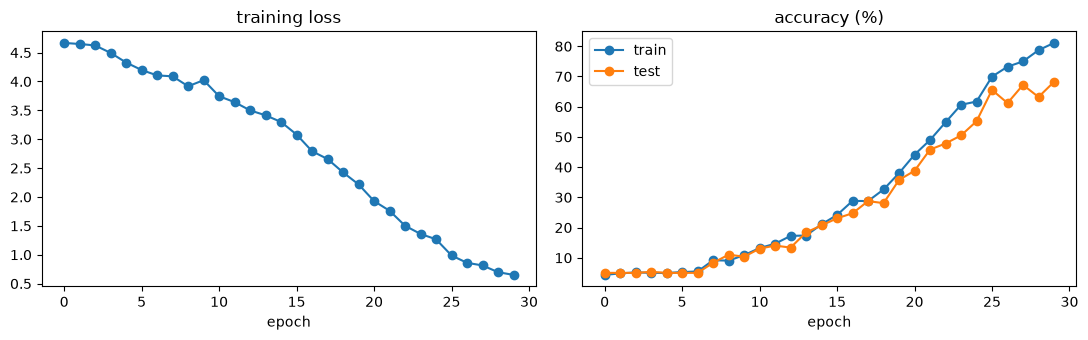

best held-out accuracy: 68.22742474916387 %
random guessing baseline: 0.93% (1 in 107)


In [ ]:
plot_history(history)
print("best held-out accuracy:", max(h["test_acc"] for h in history), "%")
print(f"random guessing baseline: {100 / N_CLASSES:.2f}% (1 in {N_CLASSES})")

# Section 5 — Prediction and validation

Three checks, in increasing usefulness:
1. the raw error rate,
2. *which* identities it confuses (confusion matrix),
3. *what* it got wrong (look at the images).

Step 3 is the one that tells you what to fix.

In [ ]:
@torch.no_grad()
def predict(model, x):
    """Returns (predicted class, confidence). Softmax turns raw scores into probabilities."""
    model.eval()
    probs = F.softmax(model(x.to(DEVICE)), dim=1)
    conf, pred = probs.max(1)
    return pred.cpu(), conf.cpu()


x, y = next(iter(test_loader))
pred, conf = predict(model, x[:8])
for i in range(8):
    mark = "ok " if pred[i] == y[i] else "XX "
    print(f"{mark} true tiger#{int(y[i])}  predicted tiger#{int(pred[i])}  confidence {conf[i]:.1%}")

ok  true tiger#93  predicted tiger#93  confidence 99.6%
ok  true tiger#93  predicted tiger#93  confidence 98.8%
ok  true tiger#93  predicted tiger#93  confidence 99.6%
XX  true tiger#97  predicted tiger#16  confidence 38.6%
ok  true tiger#97  predicted tiger#97  confidence 96.1%
XX  true tiger#97  predicted tiger#52  confidence 18.5%
XX  true tiger#62  predicted tiger#102  confidence 38.1%
ok  true tiger#62  predicted tiger#62  confidence 83.3%


held-out accuracy 68.23%   error rate 31.77%   misclassified 95


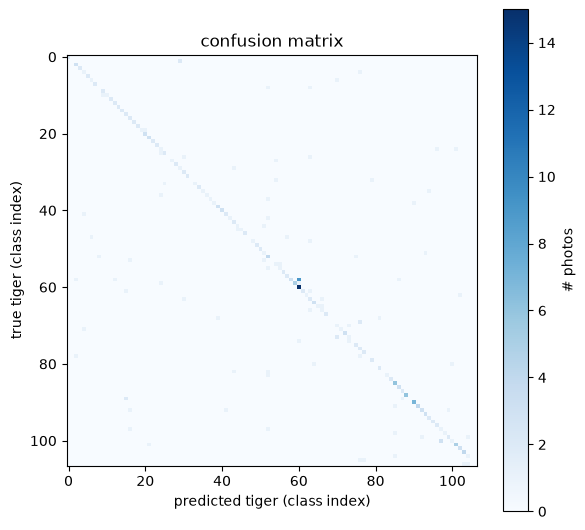

In [ ]:
# Full held-out set: accuracy + confusion matrix.
@torch.no_grad()
def evaluate(model, loader, n_classes):
    model.eval()
    cm = torch.zeros(n_classes, n_classes, dtype=torch.long)   # rows = true, cols = predicted
    wrong_x, wrong_true, wrong_pred = [], [], []
    for x, y in loader:
        p = model(x.to(DEVICE)).argmax(1).cpu()
        for t, q in zip(y, p):
            cm[t, q] += 1
        bad = p != y
        if bad.any():
            wrong_x.append(x[bad]); wrong_true.append(y[bad]); wrong_pred.append(p[bad])
    acc = 100.0 * cm.diag().sum().item() / cm.sum().item()
    if wrong_x:
        wrong = (torch.cat(wrong_x), torch.cat(wrong_true), torch.cat(wrong_pred))
    else:
        wrong = (torch.empty(0), torch.empty(0), torch.empty(0))
    return acc, cm, wrong


acc, cm, wrong = evaluate(model, test_loader, N_CLASSES)
print(f"held-out accuracy {acc:.2f}%   error rate {100 - acc:.2f}%   misclassified {len(wrong[0])}")

# 107x107 is too big for per-cell numbers or tick labels, so just show the heatmap: a strong
# diagonal means the network tells tigers apart; scattered off-diagonal mass is the confusion.
fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("predicted tiger (class index)"); ax.set_ylabel("true tiger (class index)")
ax.set_title("confusion matrix")
plt.colorbar(im, ax=ax, label="# photos")
plt.tight_layout(); plt.show()

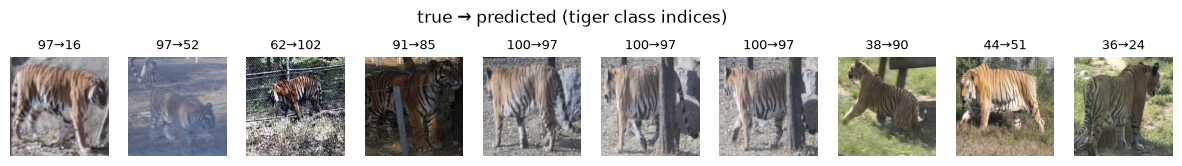

In [ ]:
# Look at the mistakes. The paper does the same for MNIST (its Figure 8 shows all 82 errors);
# for tigers, expect confusions between individuals with similar stripe patterns or poses.
n = min(10, len(wrong[0]))
if n:
    fig, axes = plt.subplots(1, n, figsize=(1.5 * n, 2))
    for ax, img, t, p in zip(axes, wrong[0][:n], wrong[1][:n], wrong[2][:n]):
        ax.imshow(unnormalize(img)); ax.set_title(f"{int(t)}→{int(p)}", fontsize=9)
        ax.axis("off")
    plt.suptitle("true → predicted (tiger class indices)"); plt.show()
else:
    print("no mistakes on this run")

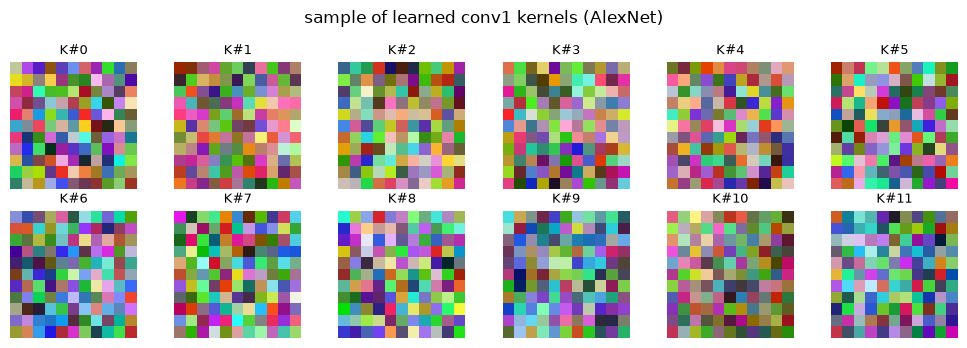

In [ ]:
# What did conv1 actually learn? Each 11x11x3 tile is one kernel: an RGB colour/edge detector.
# Min-max normalised per kernel for display, since raw weights aren't in 0..1.
k = model.features[0].weight.detach().cpu()          # (96, 3, 11, 11)
fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))
for i, ax in enumerate(axes.ravel()):
    tile = k[i].permute(1, 2, 0)                      # (11,11,3)
    tile = (tile - tile.min()) / (tile.max() - tile.min() + 1e-8)
    ax.imshow(tile); ax.set_title(f"K#{i}", fontsize=9); ax.axis("off")
plt.suptitle("sample of learned conv1 kernels (VGG)")
plt.tight_layout(); plt.show()

# Section 6 — Glossary

**Tensor** — an n-dimensional array. An image batch is a 4-D tensor `(batch, channels, height, width)`.

**Channel / feature map** — one 2-D slice of a layer's output. A conv layer outputs many feature maps.

**Kernel / filter** — the small grid of weights slid over the input. What the conv layer learns.

**Convolution** — sliding a kernel across the image, computing weighted sums at each position.

**Weight sharing** — the same kernel is reused at all positions, which keeps parameters manageable.

**Stride** — how far the kernel moves each step. Larger stride downsamples faster.

**Padding** — extra border pixels used to control output size and edge behavior.

**Pooling** — shrinking feature maps (here max pooling), which adds translation tolerance.

**Activation** — non-linearity after linear layers. VGG also uses ReLU after each convolution.

**Max-pooling** — down-sampling between stages in VGG, keeping the representation compact and translation-tolerant.

**Dropout** — randomly zeroes features during training to reduce overfitting.

**Fully connected (dense) layer** — every input connects to every output; parameter-heavy classifier layers.

**Logits** — raw class scores before softmax.

**Softmax** — turns logits into probabilities summing to 1.

**Loss function** — one scalar that measures prediction error. Cross-entropy is used here.

**Gradient** — derivative of loss w.r.t. parameter; direction and magnitude for updates.

**Back-propagation** — chain rule through the network to compute all gradients.

**Optimiser** — update rule that uses gradients to change parameters. Here: SGD with momentum.

**Learning rate** — update step size.

**Epoch** — one full pass over training data. **Batch** — subset processed before one update.

**Parameter** — learnable weight or bias. **Hyperparameter** — user-set value (lr, batch size, epochs).

**Training / validation split** — data used to fit vs. data used for held-out performance checks.

**Overfitting** — high training performance but weak held-out performance.

**Confusion matrix** — table of true vs. predicted classes. Off-diagonal mass = mistakes.

**`model.train()` / `model.eval()`** — switches training/inference behavior for layers like dropout.

**`zero_grad()`** — clears accumulated gradients before backpropagating the next batch.

**`torch.no_grad()`** — disables gradient tracking during evaluation; faster and lighter.

## Next steps

Change one thing, re-run `fit`, compare the held-out accuracy:

| Try | What it tells you |
|---|---|
| add `transforms.RandomHorizontalFlip()` | whether simple augmentation improves generalisation |
| add `transforms.RandomResizedCrop(227, scale=(0.8, 1.0))` | whether crop diversity helps identity robustness |
| lower LR after plateaus (e.g. `StepLR`) | whether optimisation, not architecture, is the bottleneck |
| reduce FC size (4096 -> 2048) | whether model is over-capacity for ATRW scale |
| freeze `features` for first few epochs | whether classifier-only warmup stabilises training |
| switch to Adam (`lr=1e-4`) | optimiser sensitivity on this dataset |

Change **one** at a time, and write down the number each time. That's how you learn which part
of the setup is actually carrying the result.

## Save results

Persist the trained model and validation metrics to `runs/<name>/`, so this run survives a kernel restart and can be compared against the other notebooks later.


In [ ]:
# Save the trained model + validation results into runs/n3_vgg/, so this run isn't lost.
import json
from pathlib import Path

RUN_DIR = Path("runs") / "n3_vgg"
RUN_DIR.mkdir(parents=True, exist_ok=True)

torch.save({"model_state": model.state_dict(), "history": history}, RUN_DIR / "model.pt")

with open(RUN_DIR / "metrics.json", "w") as f:
    json.dump({
        "held_out_accuracy": acc,
        "best_test_acc_during_training": max(h["test_acc"] for h in history) if history else None,
        "misclassified": len(wrong[0]),
        "history": history,
    }, f, indent=2)

print("saved model + metrics to", RUN_DIR.resolve())
